In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("../extraction/clientRaw.csv", sep=";")

df

C:\Users\Nicolas Pozdena\AppData\Local\Temp\ipykernel_8700\2273380339.py:1: DtypeWarning: Columns (83,183,186,187,194,198,200,201) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../extraction/clientRaw.csv", sep=";")


,nationalityId,genderId,id,dateOfBirth,admin-zone,admin-packet,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,kein-internet,...,haushalt-2pers-betreuung-nein,haushalt-2pers-betreuung-ja,haushalt-2pers-bewilligte-pflegestufe,akonto-datum,adrech-andere,schlaf-nacht-aufsteg-betreuung-ja-kommentar,foerderung_keine,verbandswechsel,generalPractitioner,abrech-keinfeiertagszuschlag
0,NaN,M,24eee8b3-9688-7a37-0e55-92b919444684,19360503.0,Zone 4,Sonstige,True,False,False,True,...,False,False,NaN,NaN,NaN,NaN,False,False,NaN,False
1,NaN,M,98a7f4bb-4b1d-76f5-71b3-0fb6b9528d9d,19681115.0,Zone 4,Sonstige,True,False,False,True,...,False,False,NaN,NaN,NaN,NaN,False,False,NaN,False
2,NaN,M,dbe1dce3-4b4c-2825-5340-8bf455359434,19320721.0,Zone 5,Sonstige,True,False,False,True,...,False,False,NaN,NaN,NaN,NaN,False,False,NaN,False
3,NaN,F,c2537299-8715-16db-6207-baf55bd7c252,19401204.0,Zone 1,Sonstige,True,False,False,True,...,False,False,NaN,NaN,NaN,NaN,False,False,NaN,False
4,NaN,M,d071a0c8-c46a-36e0-2387-5cf8faa28bc8,19351009.0,Zone 2,Sonstige,True,False,False,True,...,False,False,NaN,NaN,NaN,NaN,False,False,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11101,NaN,NaN,e60ae476-76b2-4929-be11-ab9a30895d00,19361030.0,Zone 7,Palliativbegleitung,True,False,False,False,...,False,False,NaN,NaN,"Preuner, Alexandra",NaN,False,False,NaN,False
11102,NaN,NaN,6742cd5e-20d8-400c-a1d7-c2043d91507a,19430519.0,Zone 2,Demenzbetreuung,True,False,False,False,...,False,False,NaN,NaN,NaN,NaN,False,False,NaN,False
11103,NaN,NaN,eebcbedb-bd8e-4a79-8d46-5c951a1d5def,19580502.0,Zone 9,Kurzzeit-Urlaubsvertetung,True,False,False,False,...,False,False,NaN,NaN,NaN,bei Bedarf Medikamente und evtl. Toilette,False,False,NaN,False
11104,NaN,NaN,09c40bdb-5ff4-442c-9279-3aa1cefbd6a3,19650821.0,Zone 6,Premium,True,False,False,False,...,False,False,NaN,NaN,"Nadler, Karin",NaN,False,False,NaN,False


In [5]:
def eda_summary(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "count": df.count(),
        "missing": df.isna().sum(),
        "missing_%": df.isna().mean() * 100,
        "unique": df.nunique(dropna=True),
    })

    summary["min"] = df.select_dtypes(include="number").min()
    summary["mean"] = df.select_dtypes(include="number").mean()
    summary["median"] = df.select_dtypes(include="number").median()
    summary["max"] = df.select_dtypes(include="number").max()

    return summary.round(2)

summary = eda_summary(df)
summary.to_csv("summary.csv", sep=";")

In [6]:
summary

,dtype,count,missing,missing_%,unique,min,mean,median,max
nationalityId,float64,0,11106,100.00,0,NaN,NaN,NaN,NaN
genderId,object,10941,165,1.49,3,NaN,NaN,NaN,NaN
id,object,11106,0,0.00,11106,NaN,NaN,NaN,NaN
dateOfBirth,float64,11089,17,0.15,6934,19000101.0,19374419.8,19360924.0,20260330.0
admin-zone,object,9333,1773,15.96,12,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
schlaf-nacht-aufsteg-betreuung-ja-kommentar,object,33,11073,99.70,29,NaN,NaN,NaN,NaN
foerderung_keine,bool,11106,0,0.00,1,NaN,NaN,NaN,NaN
verbandswechsel,bool,11106,0,0.00,1,NaN,NaN,NaN,NaN
generalPractitioner,float64,0,11106,100.00,0,NaN,NaN,NaN,NaN


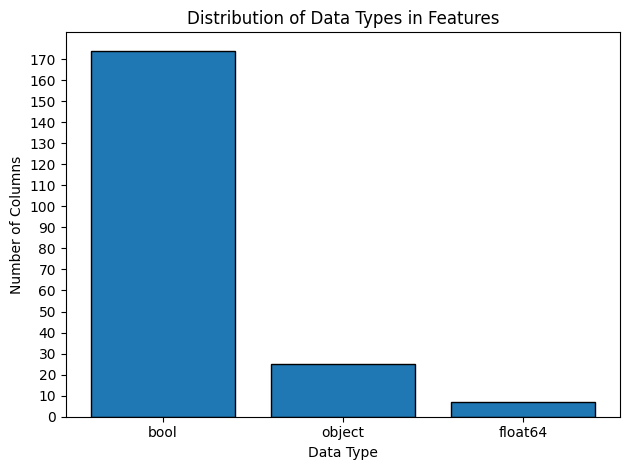

In [7]:
dtypes = summary["dtype"].astype(str).value_counts()

plt.bar(
    dtypes.index,
    dtypes.values,
    edgecolor="black"
)

plt.title("Distribution of Data Types in Features")
plt.xlabel("Data Type")
plt.ylabel("Number of Columns")

plt.yticks(
    np.arange(0, dtypes.max() + 5, 10)
)

plt.tight_layout()
plt.show()

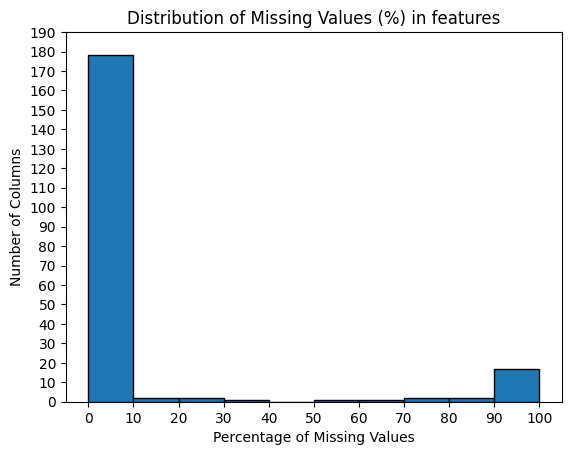

In [8]:
plt.hist(summary["missing_%"], bins=10, edgecolor='black')
plt.title("Distribution of Missing Values (%) in features")
plt.xlabel("Percentage of Missing Values")
plt.ylabel("Number of Columns")
plt.xticks(np.arange(0, 101, 10))
plt.yticks(np.arange(0, 200, 10))
plt.show()

In [9]:
df_dropped = df.drop(columns = summary[summary["missing_%"] >= 10].index)

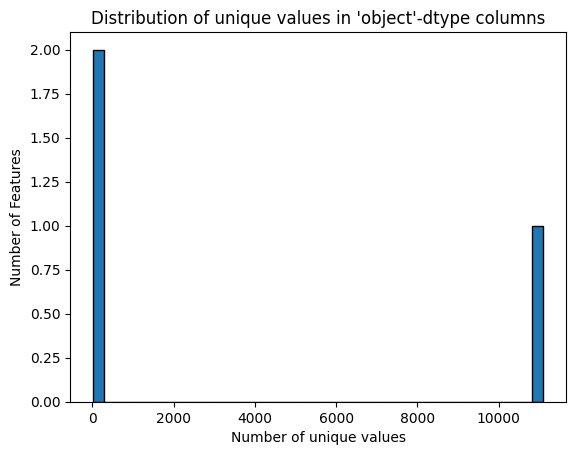

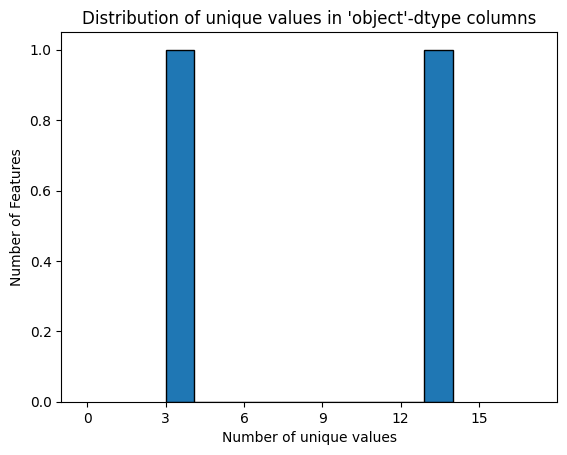

In [10]:


plt.hist(summary[(summary["missing_%"] < 10) & (summary["dtype"] == "object")]["unique"], bins=40, edgecolor='black')
plt.title("Distribution of unique values in 'object'-dtype columns")
plt.xlabel("Number of unique values")
plt.ylabel("Number of Features")

plt.show()

plt.hist(summary[(summary["missing_%"] < 10) & (summary["dtype"] == "object") & (summary["unique"] <= 1000)]["unique"], bins=10, edgecolor='black')
plt.title("Distribution of unique values in 'object'-dtype columns")
plt.xlabel("Number of unique values")
plt.xticks(np.arange(0,17,3))
plt.xlim(-1,18)
plt.ylabel("Number of Features")
plt.show()

In [11]:
summary[(summary["missing_%"] < 10) & (summary["dtype"] == "object") & (summary["unique"] <= 100)]

,dtype,count,missing,missing_%,unique,min,mean,median,max
genderId,object,10941,165,1.49,3,NaN,NaN,NaN,NaN
admin-packet,object,9998,1108,9.98,14,NaN,NaN,NaN,NaN


In [12]:
df_dropped["genderId"] = df_dropped["genderId"].where(
    df_dropped["genderId"].isin(["M", "F"]),
    "fam"
)

In [13]:
df_dropped["admin-packet"].unique()

array(['Sonstige', 'KH-Nachversorgung', nan, 'ZZ_Standard Plus', 'Basis',
       'ZZ_Pflegerin', 'CD Perle', 'ZZ_Pflege leicht', 'Premium',
       'Diplomierte Fachkraft', 'Klassik', 'Palliativbegleitung',
       'CD Perle Plus', 'Kurzzeit-Urlaubsvertetung', 'Demenzbetreuung'],
      dtype=object)

In [14]:
pflege_map = {
    "ZZ_Pflegerin": 60,
    "Diplomierte Fachkraft": 130,
    "Klassik": 90,
    "Premium": 95,
    "ZZ_Standard Plus": 82,
    "Basis": 69,
    "Palliativbegleitung": 100,
    "CD Perle": 89,
    "Demenzbetreuung": 95,
    "ZZ_Pflege leicht": 59,
    "ZZ_Springerin": 69,
    "CD Perle Plus": 125,
}

average = sum(pflege_map.values()) / len(pflege_map)

In [15]:
df_dropped["admin-packet"] = (
    df_dropped["admin-packet"]
    .map(pflege_map)
    .fillna(average)
)

In [16]:
df_dropped["admin-packet"].unique()

array([ 88.58333333,  82.        ,  69.        ,  60.        ,
        89.        ,  59.        ,  95.        , 130.        ,
        90.        , 100.        , 125.        ])

In [17]:
columns_to_encode = [
    "genderId"
]

df_encoded = pd.get_dummies(
    df_dropped,
    columns=columns_to_encode,
    dtype=int,
	drop_first=True
)

In [18]:
df_encoded

,id,dateOfBirth,admin-packet,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,kein-internet,vor-ort,von-curadomo,kommunikaiton-sms,...,hilfsmittel-wechseldruckmatratze,Klient:innen_Haushalt_Sonstiges_Ja,unterstuetzung-pflanzen-tiere,haushalt-2pers-betreuung-nein,haushalt-2pers-betreuung-ja,foerderung_keine,verbandswechsel,abrech-keinfeiertagszuschlag,genderId_M,genderId_fam
0,24eee8b3-9688-7a37-0e55-92b919444684,19360503.0,88.583333,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,1,0
1,98a7f4bb-4b1d-76f5-71b3-0fb6b9528d9d,19681115.0,88.583333,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,1,0
2,dbe1dce3-4b4c-2825-5340-8bf455359434,19320721.0,88.583333,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,1,0
3,c2537299-8715-16db-6207-baf55bd7c252,19401204.0,88.583333,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,0,0
4,d071a0c8-c46a-36e0-2387-5cf8faa28bc8,19351009.0,88.583333,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11101,e60ae476-76b2-4929-be11-ab9a30895d00,19361030.0,100.000000,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,0,1
11102,6742cd5e-20d8-400c-a1d7-c2043d91507a,19430519.0,95.000000,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,0,1
11103,eebcbedb-bd8e-4a79-8d46-5c951a1d5def,19580502.0,88.583333,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,0,1
11104,09c40bdb-5ff4-442c-9279-3aa1cefbd6a3,19650821.0,95.000000,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,0,1


In [19]:

df_encoded["dateOfBirth"] = pd.to_datetime(
    df_encoded["dateOfBirth"].astype("Int64").astype("string"),
    format="%Y%m%d",
    errors="coerce"
)



In [20]:
df_encoded

,id,dateOfBirth,admin-packet,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,kein-internet,vor-ort,von-curadomo,kommunikaiton-sms,...,hilfsmittel-wechseldruckmatratze,Klient:innen_Haushalt_Sonstiges_Ja,unterstuetzung-pflanzen-tiere,haushalt-2pers-betreuung-nein,haushalt-2pers-betreuung-ja,foerderung_keine,verbandswechsel,abrech-keinfeiertagszuschlag,genderId_M,genderId_fam
0,24eee8b3-9688-7a37-0e55-92b919444684,1936-05-03,88.583333,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,1,0
1,98a7f4bb-4b1d-76f5-71b3-0fb6b9528d9d,1968-11-15,88.583333,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,1,0
2,dbe1dce3-4b4c-2825-5340-8bf455359434,1932-07-21,88.583333,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,1,0
3,c2537299-8715-16db-6207-baf55bd7c252,1940-12-04,88.583333,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,0,0
4,d071a0c8-c46a-36e0-2387-5cf8faa28bc8,1935-10-09,88.583333,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11101,e60ae476-76b2-4929-be11-ab9a30895d00,1936-10-30,100.000000,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,0,1
11102,6742cd5e-20d8-400c-a1d7-c2043d91507a,1943-05-19,95.000000,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,0,1
11103,eebcbedb-bd8e-4a79-8d46-5c951a1d5def,1958-05-02,88.583333,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,0,1
11104,09c40bdb-5ff4-442c-9279-3aa1cefbd6a3,1965-08-21,95.000000,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,0,1


                              nunique  most_common_pct
abrech-keinfeiertagszuschlag        1       100.000000
foerderung_land                     1       100.000000
Klient:innen_Austritt_Ja            1       100.000000
verbandswechsel                     1       100.000000
foerderung_keine                    1       100.000000
...                               ...              ...
Klient:innen_lebt_alleine_Ja        2        50.621286
wohnart-wohnung                     2        50.171079
admin-packet                       11        46.911579
dateOfBirth                      6934         0.315145
id                              11106         0.009004

[179 rows x 2 columns]


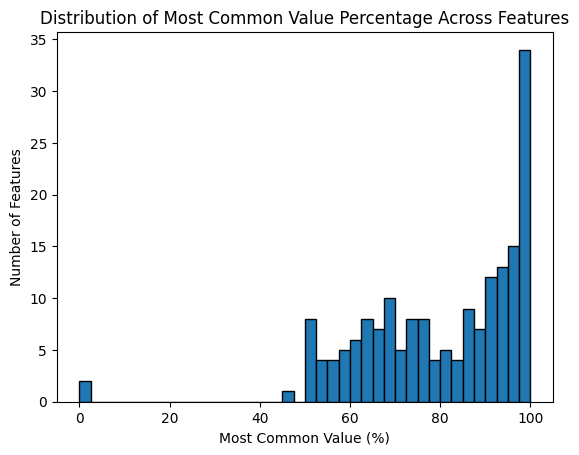

In [21]:
feature_summary = pd.DataFrame({
    "nunique": df_encoded.nunique(),
    "most_common_pct": df_encoded.apply(
        lambda col: col.value_counts(normalize=True, dropna=False).iloc[0] * 100
    )
})

print(feature_summary.sort_values("most_common_pct", ascending=False))

plt.hist(feature_summary["most_common_pct"], bins= 40, edgecolor="black")
plt.title("Distribution of Most Common Value Percentage Across Features")
plt.xlabel("Most Common Value (%)")
plt.ylabel("Number of Features")
plt.show()

In [22]:
df_y = df_encoded

In [23]:

df_y["birthYear"] = df_y["dateOfBirth"].dt.year
df_y["birthMonth"] = df_y["dateOfBirth"].dt.month



df_y

,id,dateOfBirth,admin-packet,admin-bankkonto-kreditor-schwechat,admin-bankkonto-kreditor-sensivita,admin-bankkonto-kreditor-cda,kein-internet,vor-ort,von-curadomo,kommunikaiton-sms,...,unterstuetzung-pflanzen-tiere,haushalt-2pers-betreuung-nein,haushalt-2pers-betreuung-ja,foerderung_keine,verbandswechsel,abrech-keinfeiertagszuschlag,genderId_M,genderId_fam,birthYear,birthMonth
0,24eee8b3-9688-7a37-0e55-92b919444684,1936-05-03,88.583333,True,False,False,True,False,False,True,...,False,False,False,False,False,False,1,0,1936.0,5.0
1,98a7f4bb-4b1d-76f5-71b3-0fb6b9528d9d,1968-11-15,88.583333,True,False,False,True,False,False,True,...,False,False,False,False,False,False,1,0,1968.0,11.0
2,dbe1dce3-4b4c-2825-5340-8bf455359434,1932-07-21,88.583333,True,False,False,True,False,False,True,...,False,False,False,False,False,False,1,0,1932.0,7.0
3,c2537299-8715-16db-6207-baf55bd7c252,1940-12-04,88.583333,True,False,False,True,False,False,False,...,False,False,False,False,False,False,0,0,1940.0,12.0
4,d071a0c8-c46a-36e0-2387-5cf8faa28bc8,1935-10-09,88.583333,True,False,False,True,False,False,False,...,False,False,False,False,False,False,1,0,1935.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11101,e60ae476-76b2-4929-be11-ab9a30895d00,1936-10-30,100.000000,True,False,False,False,False,True,False,...,False,False,False,False,False,False,0,1,1936.0,10.0
11102,6742cd5e-20d8-400c-a1d7-c2043d91507a,1943-05-19,95.000000,True,False,False,False,True,False,False,...,False,False,False,False,False,False,0,1,1943.0,5.0
11103,eebcbedb-bd8e-4a79-8d46-5c951a1d5def,1958-05-02,88.583333,True,False,False,False,False,False,False,...,False,False,False,False,False,False,0,1,1958.0,5.0
11104,09c40bdb-5ff4-442c-9279-3aa1cefbd6a3,1965-08-21,95.000000,True,False,False,False,True,False,False,...,False,False,False,False,False,False,0,1,1965.0,8.0


In [24]:
df_y.drop(columns="dateOfBirth", inplace=True)

In [25]:
df_final = df_y.drop(columns=feature_summary[feature_summary["most_common_pct"]>99].index)
df_final

,id,admin-packet,kein-internet,vor-ort,von-curadomo,kommunikaiton-sms,wohnart-einfamilienhaus,wohnart-wohnung,person-2-nicht-mit-betreut,person-2-pflegestufe-0-2,...,qual-de-basis,qual-de-einfach,qual-de-gehoben,mobiler-dienst-weiterhin-nein,mobiler-dienst-weiterhin-ja,tiere-versorgen,genderId_M,genderId_fam,birthYear,birthMonth
0,24eee8b3-9688-7a37-0e55-92b919444684,88.583333,True,False,False,True,False,True,True,False,...,False,False,False,False,False,False,1,0,1936.0,5.0
1,98a7f4bb-4b1d-76f5-71b3-0fb6b9528d9d,88.583333,True,False,False,True,False,True,True,False,...,False,False,True,False,False,False,1,0,1968.0,11.0
2,dbe1dce3-4b4c-2825-5340-8bf455359434,88.583333,True,False,False,True,False,True,True,False,...,False,False,False,True,False,False,1,0,1932.0,7.0
3,c2537299-8715-16db-6207-baf55bd7c252,88.583333,True,False,False,False,True,False,True,False,...,False,False,True,False,False,False,0,0,1940.0,12.0
4,d071a0c8-c46a-36e0-2387-5cf8faa28bc8,88.583333,True,False,False,False,True,False,True,False,...,False,False,False,False,False,False,1,0,1935.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11101,e60ae476-76b2-4929-be11-ab9a30895d00,100.000000,False,False,True,False,False,True,False,False,...,False,False,True,False,False,False,0,1,1936.0,10.0
11102,6742cd5e-20d8-400c-a1d7-c2043d91507a,95.000000,False,True,False,False,True,False,False,False,...,False,False,True,False,False,False,0,1,1943.0,5.0
11103,eebcbedb-bd8e-4a79-8d46-5c951a1d5def,88.583333,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,0,1,1958.0,5.0
11104,09c40bdb-5ff4-442c-9279-3aa1cefbd6a3,95.000000,False,True,False,False,True,False,False,False,...,False,False,True,False,True,False,0,1,1965.0,8.0


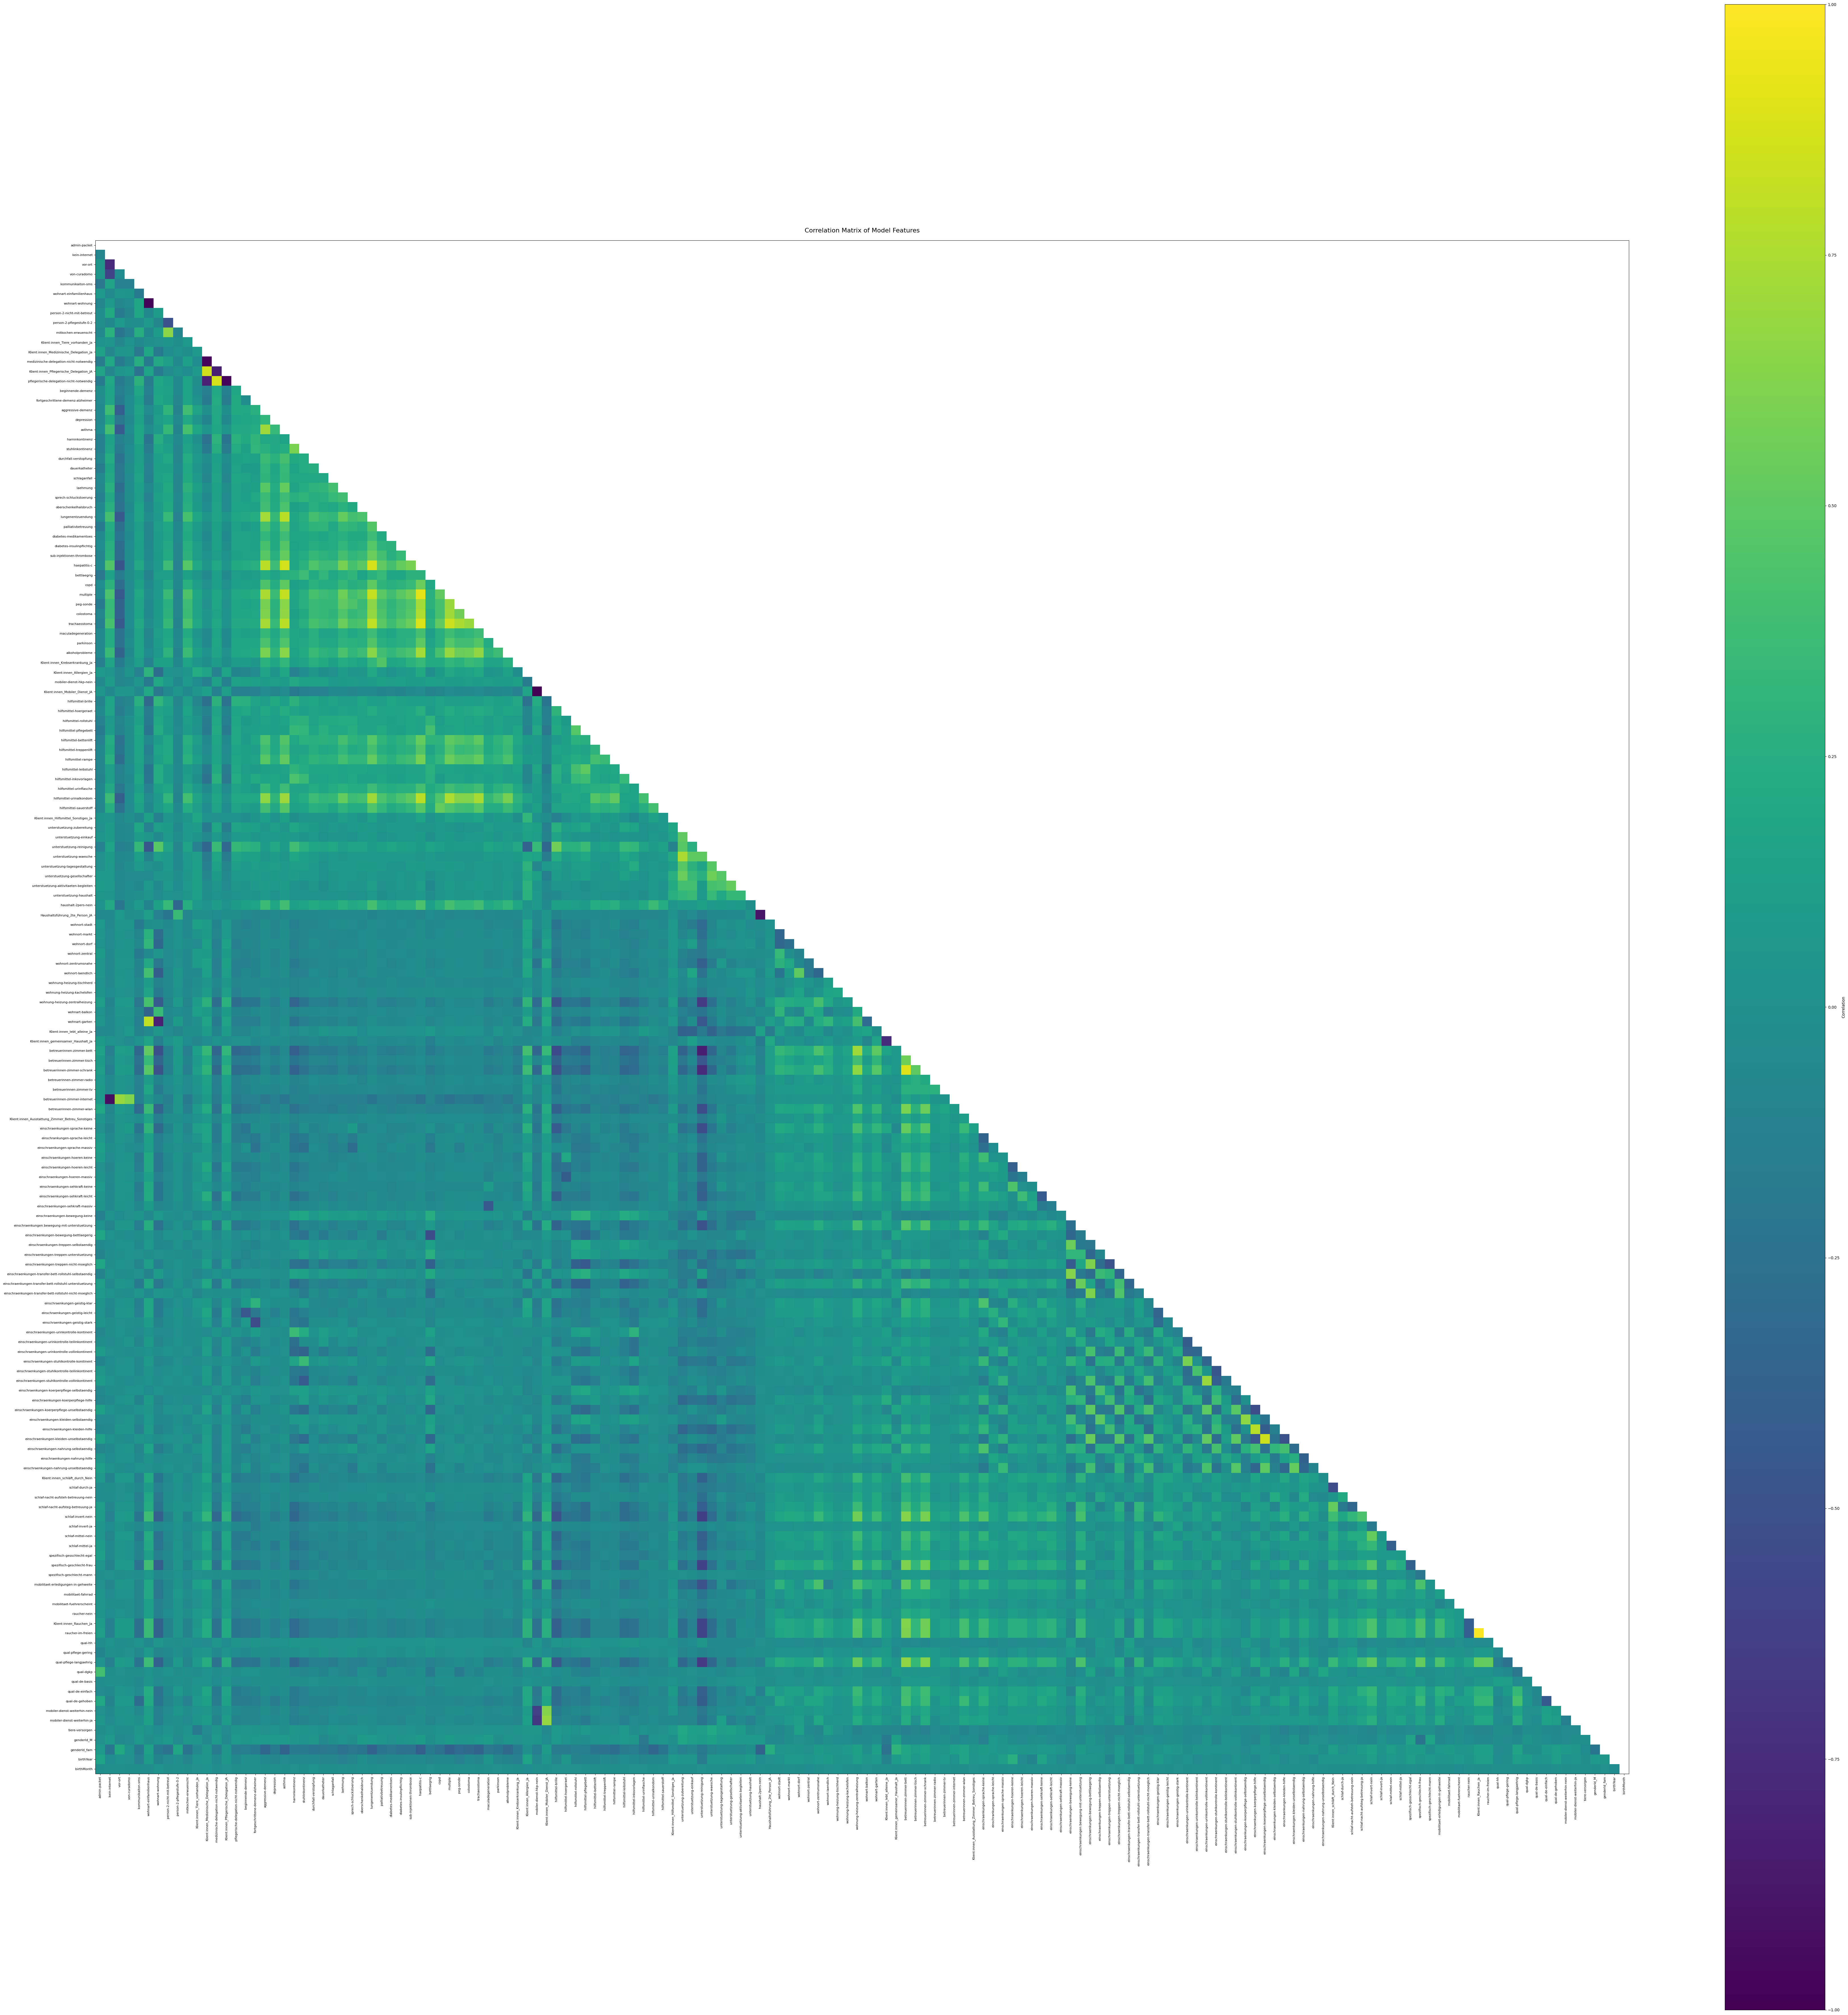

In [26]:
corr = df_final.corr(numeric_only=True)

# Hide upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Dynamic figure size
n_features = len(corr.columns)
figsize = max(12, n_features * 0.45)

fig, ax = plt.subplots(figsize=(figsize, figsize))

# Mask upper triangle
corr_masked = np.ma.masked_where(mask, corr.values)

im = ax.imshow(
    corr_masked,
    vmin=-1,
    vmax=1,
    aspect="equal"
)

fig.colorbar(im, ax=ax, label="Correlation")

ax.set_xticks(range(n_features))
ax.set_yticks(range(n_features))

ax.set_xticklabels(
    corr.columns,
    rotation=90,
    fontsize=8
)

ax.set_yticklabels(
    corr.columns,
    fontsize=8
)

ax.set_title(
    "Correlation Matrix of Model Features",
    fontsize=16,
    pad=20
)

plt.tight_layout()
plt.show()

In [27]:
corr = df_final.corr(numeric_only=True)

threshold = 0.8

strong_corr = corr.where(
    (corr.abs() >= threshold) & (corr.abs() < 1)
)

# Remove features that have no strong correlations
keep = strong_corr.notna().any()

strong_corr = strong_corr.loc[keep, keep]

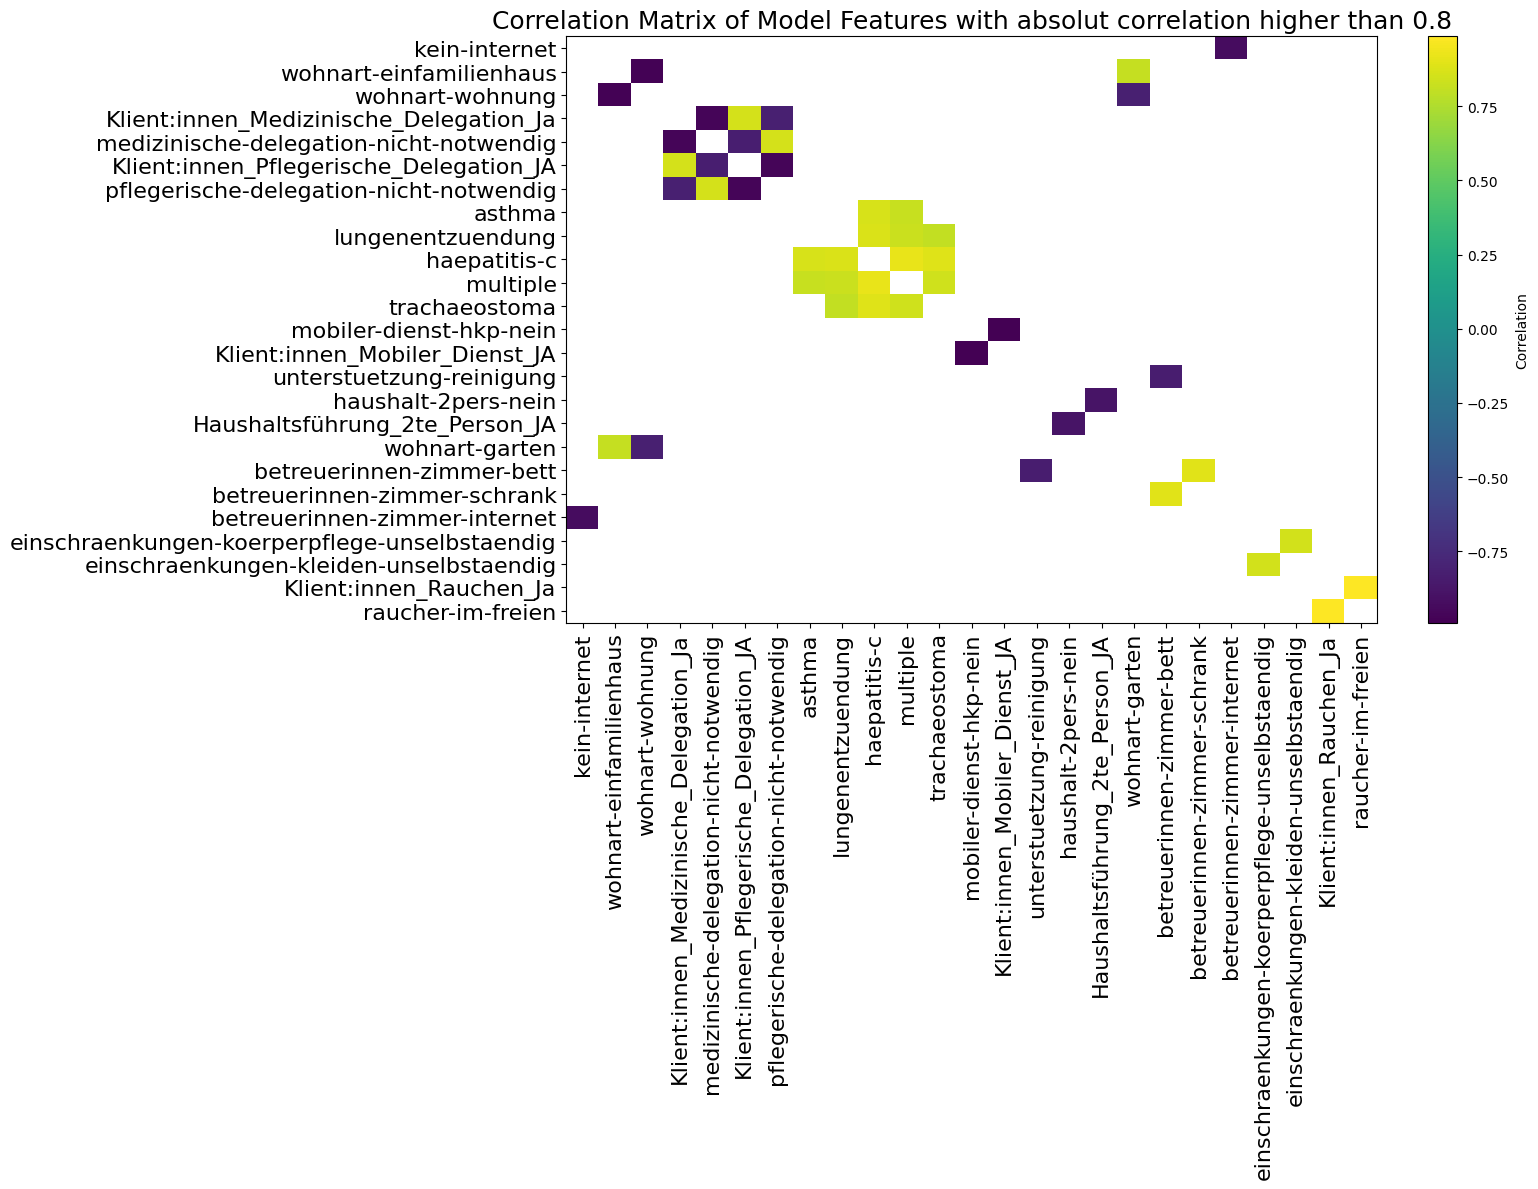

In [28]:
corr_matrix = strong_corr

plt.figure(figsize=(16, 12))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90,
	fontsize=16
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
	fontsize=16
)

plt.title("Correlation Matrix of Model Features with absolut correlation higher than 0.8", fontsize=18)
plt.tight_layout()
plt.show()

In [29]:
def remove_correlated_features(df, threshold=0.8, exclude=["id"]):

    result = df.copy()
    dropped = []

    while True:

        features = result.drop(
            columns=exclude,
            errors="ignore"
        )

        corr = features.corr().abs()

        # Remove diagonal
        np.fill_diagonal(corr.values, 0)

        # Find strongest remaining correlation
        max_corr = corr.max().max()

        if max_corr <= threshold:
            break

        # Find the pair
        var1, var2 = corr.stack().idxmax()

        # Mean absolute correlation with all other variables
        score1 = corr.loc[var1].mean()
        score2 = corr.loc[var2].mean()

        # Drop the more redundant variable
        if score1 > score2:
            drop = var1
        else:
            drop = var2

        dropped.append({
            "dropped": drop,
            "var1": var1,
            "var2": var2,
            "pair_corr": max_corr,
            "score_var1": score1,
            "score_var2": score2
        })

        result = result.drop(columns=drop)

    return result, pd.DataFrame(dropped)

In [30]:
df_final_cleaned, dropped =  remove_correlated_features(df_final)

dropped

,dropped,var1,var2,pair_corr,score_var1,score_var2
0,mobiler-dienst-hkp-nein,mobiler-dienst-hkp-nein,Klient:innen_Mobiler_Dienst_JA,0.990045,0.125947,0.116640
1,Klient:innen_Rauchen_Ja,Klient:innen_Rauchen_Ja,raucher-im-freien,0.985147,0.170045,0.168015
2,wohnart-wohnung,wohnart-einfamilienhaus,wohnart-wohnung,0.980384,0.142744,0.152556
3,medizinische-delegation-nicht-notwendig,Klient:innen_Medizinische_Delegation_Ja,medizinische-delegation-nicht-notwendig,0.964838,0.115649,0.148793
4,pflegerische-delegation-nicht-notwendig,Klient:innen_Pflegerische_Delegation_JA,pflegerische-delegation-nicht-notwendig,0.961564,0.104815,0.140654
5,kein-internet,kein-internet,betreuerinnen-zimmer-internet,0.923821,0.122034,0.091194
6,haepatitis-c,haepatitis-c,multiple,0.915856,0.163201,0.156361
7,betreuerinnen-zimmer-bett,betreuerinnen-zimmer-bett,betreuerinnen-zimmer-schrank,0.897697,0.225525,0.209313
8,haushalt-2pers-nein,haushalt-2pers-nein,Haushaltsführung_2te_Person_JA,0.888202,0.107299,0.059441
9,Klient:innen_Medizinische_Delegation_Ja,Klient:innen_Medizinische_Delegation_Ja,Klient:innen_Pflegerische_Delegation_JA,0.855907,0.105097,0.098778


In [31]:
df_final_cleaned["genderId_M"] = df_final_cleaned["genderId_M"].astype("bool")
df_final_cleaned["genderId_fam"] = df_final_cleaned["genderId_M"].astype("bool")

In [32]:
df_final_cleaned.to_csv("clients.csv", sep=";", index=False)